## Explore MPAS-A data over New York City

Try **MPAS-Viewer**, this notebook reads remote MPAS datasets from **THREDDS servers** and demonstrates interactive visualization of a **3 km-resolution simulation over New York City** during the remnants of **Hurricane Ida (September 2021)**.

Open the notebook in **Google Colab** and start exploring the data immediately - **No installation on your local machine or data download is required.**.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jhbravo/mpasviewer/blob/main/examples/17_remote_out_nyc.ipynb)

### Data Source

For a more detailed description of the data and its accessibility, you are advised to visit HydroShare: 

[![HydroShare Dataset](https://img.shields.io/badge/HydroShare-Dataset-blue)](https://www.hydroshare.org/resource/6be754bf29cb488b815810c35f3f0ac9/)


### THREDDS Data Service

Remote access is provided through the HydroShare THREDDS server: 

[![THREDDS Catalog](https://img.shields.io/badge/THREDDS-Catalog-green)](https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/catalog.html)

### Step 0 
For Google Colab users, uncomment and run the following cell to install the required packages. If your environment is already set up, you can skip this step and proceed to Step 1.

In [18]:
# %%capture
# !pip install git+https://github.com/jhbravo/earthcmap.git

# !pip install git+https://github.com/jhbravo/mpasviewer.git

# !pip install cartopy netcdf4 s3fs zarr rasterio rioxarray

# !pip uninstall numpy -y
# !pip install "numpy<2.0.0"

### Step 1
Importe the required libraries

In [3]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime

In [4]:
url_thredds = "https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/catalog.html" ### New York
inidt = datetime(2021, 9, 1, 13); enddt = datetime(2021, 9, 2, 12) ## NYC

list_files = scvtmesh.get_thredds_list(url_thredds, date_start=inidt, date_end=enddt)

In [5]:
# list_files

In [6]:
mpasd = scvtmesh(grid_file = 'http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc',
                 diag_list = list_files)

In [7]:
# mpasd.dataset()
mpasd.dataset(load_variables=['rainnc', 'rainc', "u10","v10","t2m",'olrtoa','refl10cm_max',])

Loaded grid_file dataset: http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc


In [8]:
mpasd.rain_rate()

In [9]:
dta = mpasd.load()

In [10]:
from earthcmap import escmap

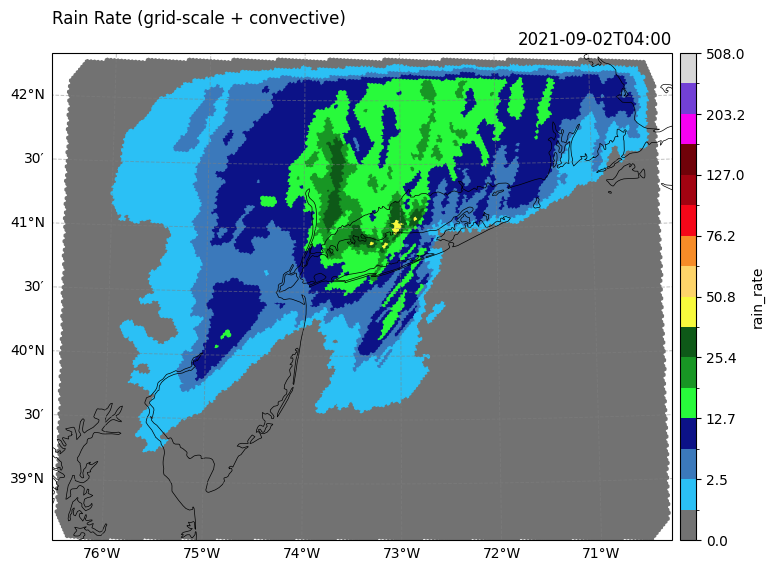

In [11]:
cmap, norm = escmap("nwps_qpe", units="mm")

mpasd.show(dta,var_name='rain_rate', time_index=15, figsize=(8,8), cmap = cmap, norm = norm,)

In [12]:
from ipywidgets import interact, Dropdown, SelectionSlider
from IPython.display import display, clear_output

In [13]:
mpas_vars = ['rain_rate', "t2m", 'olrtoa','refl10cm_max',]
cmps = {'t2m':"temp_ecmwf", 'olrtoa':"cira_ir108", 'refl10cm_max':"mrms_cref", 'rain_rate':"nwps_qpe"}
times = sorted([str(x) for x in dta['time'].data.astype('datetime64[s]')])
num_steps = len(times)

In [16]:
def update_plot(variable, time_step):
    cmap, norm = escmap(cmps[variable], units = dta[variable].attrs['units'])
    mpasd.show(dta, var_name = variable, time_index = time_step, cmap = cmap, norm = norm, figsize=(9,9))
    
# dropdown and slider widgets
variable_dropdown = Dropdown(options=mpas_vars, description='Variable:')
time_slider = SelectionSlider(
    options=times,
    value=times[5],
    description='Datetime:',
    layout={'width': '500px'},
    style={'description_width': 'initial'}
)

In [17]:
interact(update_plot, variable=variable_dropdown, time_step=time_slider)

interactive(children=(Dropdown(description='Variable:', options=('rain_rate', 't2m', 'olrtoa', 'refl10cm_max')…

<function __main__.update_plot(variable, time_step)>